# 1-body Kepler in 2D

In [2]:
import os, glob
import toml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import cycle 
from collections import defaultdict
import time

from dataprocessing_utils.onebody import OneBody, OneBodyTrajectory
from dataprocessing_utils.onebody import REF_TRAJ_FILEPATHS

Trajectory = OneBodyTrajectory

In [3]:
def plot_xy(dataset_or_trajs, axis_lims=None, linestyles=None, colors=None, legend_labels=None, axis_labels=None, 
                     title=None, figsize=(6, 4), show_legend=False, save_path=None, aspect_ratio='equal'):

    if axis_lims is None:
        axis_lims = [(None, None)] * 2  # Default axis limits

    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    elif isinstance(linestyles, str):
        linestyles = [linestyles] * len(dataset_or_trajs)

    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends

    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Default colors
    color_cycle = cycle(colors)
    
    if axis_labels is None:
        axis_labels = ['$x$', '$y$']  # Default axis labels

    fig = plt.figure(figsize=figsize, layout='constrained')
    ax = fig.subplots(1, 1)  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        u = traj.states.u 
        x, y = u[:, 2], u[:, 3]
        if legend_label == 'ref':
            line1, = ax.plot(x, y, linestyle, lw=1, markersize=1, color='k', alpha=0.3, label=legend_label)
        else:
            line1, = ax.plot(x, y, linestyle, lw=1, markersize=1, color=next(color_cycle), label=legend_label)
        lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    if axis_lims is not None:
        ax.set_xlim(axis_lims[0])
        ax.set_ylim(axis_lims[1])
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_aspect(aspect_ratio)

    if title is not None:
        ax.set_title(title)

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


def plot_history(dataset_or_trajs, func_dict, linestyles=None, alpha=1., colors=None, legend_labels=None, xlabel="t", ylabels=None, ylims=None, 
               figsize=None, log_yscale=False, log_xscale=False, show_legend=True, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    elif isinstance(linestyles, str):
        linestyles = [linestyles] * len(dataset_or_trajs)

    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends
    
    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Default colors
    color_cycle = cycle(colors)
    
    if ylabels is None:
        ylabels = list(func_dict.keys())  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * len(func_dict.keys())
    
    if figsize is None:
        figsize = (8, 1.5 * len(func_dict))

    fig, axes = plt.subplots(len(func_dict), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        xdata = traj.times if isinstance(traj, Trajectory) else np.arange(len(traj))
        color = next(color_cycle)
        for i, (key, func) in enumerate(func_dict.items()):
            if len(func_dict) > 1:
                if legend_label == 'ref':
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                else:
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, color=color, label=legend_label)
            else:
                if legend_label == 'ref':
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                else:
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, color=color, label=legend_label)
        lines.append(line1) # Append the line object for the legend

    # Set labels and titles for each subplot
    if len(func_dict) > 1:
        for i, ax in enumerate(axes):
            ax.set_ylim(ylims[i])
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabels[i])
            if log_yscale:
                ax.set_yscale('log')
            if log_xscale:
                ax.set_xscale('log')
    else:
        axes.set_ylim(ylims[0])
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabels[0])
        if log_yscale:
            axes.set_yscale('log')
        if log_xscale:
            axes.set_xscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return 


def plot_errors(trajs, ref_trajs, linestyles=None, colors=None, legend_labels=None, titles=None, error_names=None, 
                ylims=None, ylabels=None, figsize=None, log_yscale=True, log_xscale=False, show_legend=False, save_path=None):
    
    if isinstance(ref_trajs, Trajectory):
        ref_trajs = [ref_trajs] * len(trajs)
    elif isinstance(ref_trajs, list):
        assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
    else:
        raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if colors is None:
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # Default colors
    color_cycle = cycle(colors)
    
    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]
    
    if ylims is None:
        ylims = [(1e-5, 1e1)] * len(error_names)  # Default ylims for subplots
    
    if ylabels is None:
        ylabels = error_names  # Default y axis labels
    
    if figsize is None:
        figsize = (8, 1.5 * len(error_names))

    fig, axes = plt.subplots(len(error_names), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
        tt, errors = traj.compare(ref_traj)
        color = next(color_cycle)
        for i, error_name in enumerate(error_names):
            if len(error_names) > 1:
                line1, = axes[i].plot(tt[1:], errors[error_name][1:], linestyle, lw=1, color=color, label=legend_label)
            else:
                line1, = axes.plot(tt[1:], errors[error_name][1:], linestyle, lw=1, label=legend_label)
            print(f"{legend_label} n=1 {error_name} = {errors[error_name][1]}")
        lines.append(line1)
        # line1, = axes[0].plot(tt, errors[error_names[0]], linestyle, lw=1, label=legend_label)
        # axes[1].plot(tt, errors[error_names[1]], linestyle, lw=1)
        # lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])
        if log_yscale:
            ax.set_yscale('log')
        if log_xscale:
            ax.set_xscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


## Usage example

Initial state: [0.         1.73205081 0.5        0.        ]


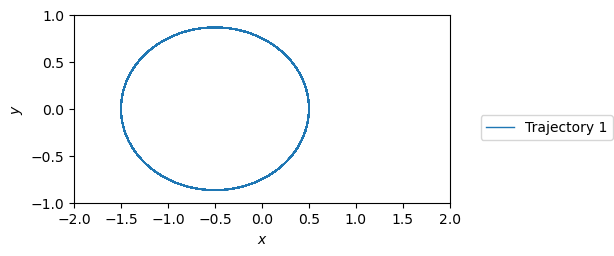

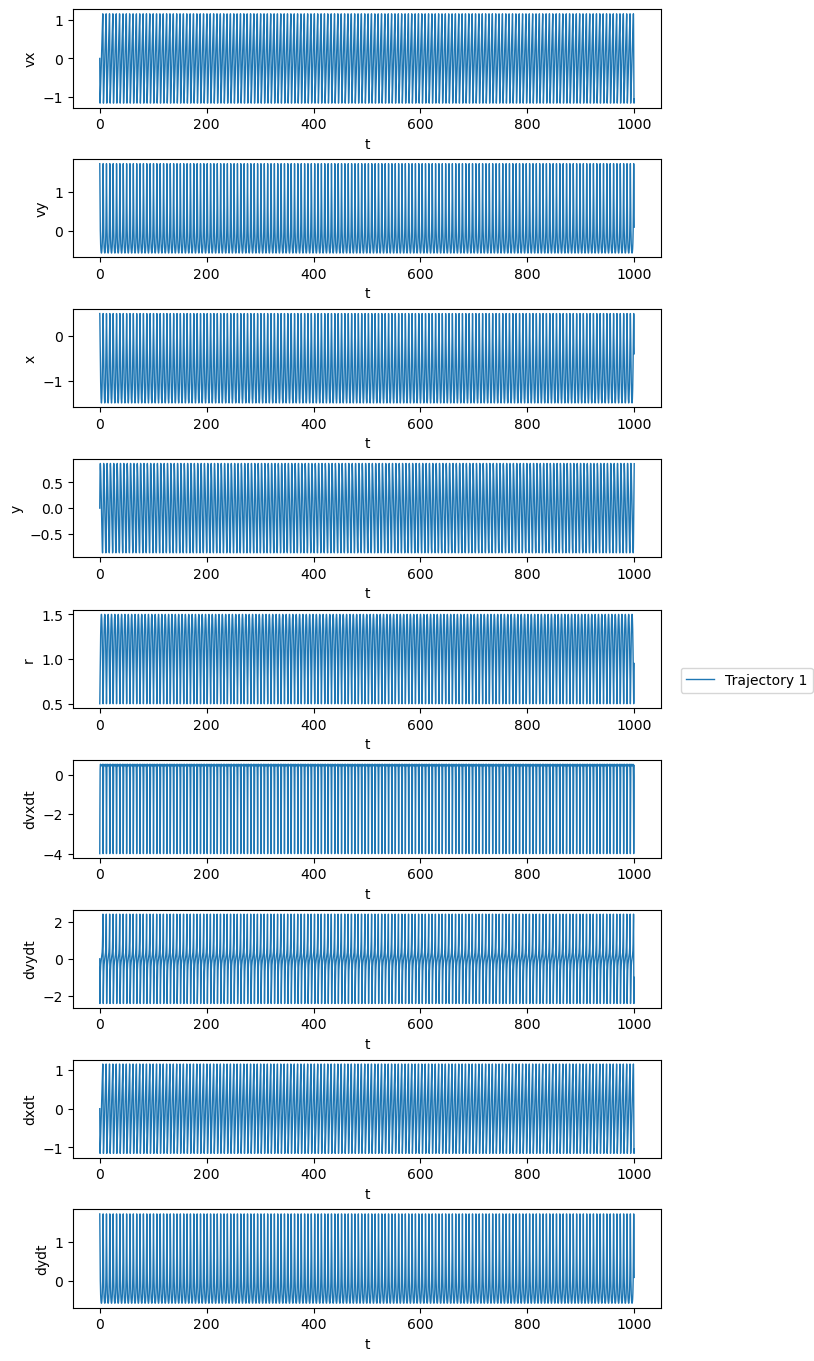

In [18]:
ecc = 0.5

traj_indices = [1]
traj_labels = ['Trajectory {}'.format(i) for i in traj_indices]
ref_trajs = [
    Trajectory.load_from_file(
        REF_TRAJ_FILEPATHS[ecc][i]["filepath"], 
        dt=REF_TRAJ_FILEPATHS[ecc][i]["dt"],
        ecc=ecc) 
    for i in traj_indices
]

processor = OneBody(ecc=ecc)

for traj in ref_trajs:
    print(f"Initial state: {traj.states.u[0]}")

trajs = [traj.select_between(0, 1000) for traj in ref_trajs]

plot_xy(
    trajs, 
    axis_lims=[(-2, 2), (-1, 1)],
    figsize=(6, 5), 
    legend_labels=traj_labels,
    show_legend=True
)

plot_history(
    trajs,
    func_dict={
        'vx': lambda u: u[:, 0], 
        'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 
        'y': lambda u: u[:, 3], 
        'r': lambda u: np.sqrt(u[:, 2]**2 + u[:, 3]**2),
        'dvxdt': lambda u: processor.compute_du(u)[:, 0],
        'dvydt': lambda u: processor.compute_du(u)[:, 1],
        'dxdt': lambda u: processor.compute_du(u)[:, 2],
        'dydt': lambda u: processor.compute_du(u)[:, 3],
    },
    xlabel='t', 
    legend_labels=traj_labels,
    show_legend=True
)

## Parareal results

In [27]:
def load_parareal_data(data_dir, K=10):
    # extract ecc and dt from config.toml file 
    config_file = os.path.join(data_dir, "config.toml")
    with open(config_file, 'r') as f:
        config = toml.load(f)
    ecc = config["problem"]["ecc"]
    dt = config["integration"]["Delta_t"]
    print("Parareal config:")
    for k, v in config.items():
        print(f"\t{k}: {v}")
    
    # load data from u.csv files
    data_files = glob.glob(os.path.join(data_dir, "*/u.csv"))
    iterations = [int(data_file.split("/")[-2].split("=")[-1]) for data_file in data_files]
    data = []
    for k, data_file in sorted(zip(iterations, data_files)):
        if k <= K:
            print(f"Loading data from {data_file}")
            data.append(Trajectory.load_from_file(data_file, dt=dt, ecc=ecc))
    return data


def plot_error_heatmaps(trajs, ref_traj, error_names=None, clims=None, figsize=None, save_path=None):

    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]
    
    if clims is None:
        clims = [(-8, 0)] * len(error_names)

    if figsize is None:
        figsize = (5, 4 * len(error_names))

    fig, axes = plt.subplots(len(error_names), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes
    
    error_matrices = defaultdict(list)
    for traj in trajs:
        tt, errors = traj.compare(ref_traj)
        for error_name in error_names:
            error_matrices[error_name].append(errors[error_name][1:])

    for i, (error_name, error_matrix_list) in enumerate(error_matrices.items()):
        error_matrix = np.array(error_matrix_list)
        im = axes[i].imshow(np.log10(error_matrix), cmap='viridis', interpolation='none', aspect='auto', clim=clims[i], 
                            extent=[tt[1], tt[-1], len(trajs), 0])
        axes[i].set_title(f"{error_name}")
        axes[i].set_xlabel("Time")
        axes[i].set_ylabel("Iteration")
        fig.colorbar(im, ax=axes[i])
    
    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return

def plot_error_diff_heatmaps(trajs1, trajs2, ref_traj, error_names=None, clims=None, figsize=None, save_path=None, 
                             min_log10_error=-8, max_log10_error=2):
    
    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]
    
    if clims is None:
        clims = [(-4, 4)] * len(error_names)

    if figsize is None:
        figsize = (5, 4 * len(error_names))

    fig, axes = plt.subplots(len(error_names), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes
    
    error_matrices1 = defaultdict(list)
    for traj in trajs1:
        tt, errors = traj.compare(ref_traj)
        for error_name in error_names:
            error_matrices1[error_name].append(errors[error_name][1:])

    error_matrices2 = defaultdict(list)
    for traj in trajs2:
        tt, errors = traj.compare(ref_traj)
        for error_name in error_names:
            error_matrices2[error_name].append(errors[error_name][1:])

    for i, (error_name, error_matrix_list1) in enumerate(error_matrices1.items()):
        error_matrix1 = np.array(error_matrix_list1)
        error_matrix2 = np.array(error_matrices2[error_name])
        error_matrix1[error_matrix1 < 10**min_log10_error] = 10**min_log10_error
        error_matrix2[error_matrix2 < 10**min_log10_error] = 10**min_log10_error
        error_matrix1[error_matrix1 > 10**max_log10_error] = 10**max_log10_error
        error_matrix2[error_matrix2 > 10**max_log10_error] = 10**max_log10_error
        log10_error_matrix_diff = np.log10(error_matrix1) - np.log10(error_matrix2)
        im = axes[i].imshow(log10_error_matrix_diff, cmap='coolwarm', interpolation='none', aspect='auto', clim=clims[i], 
                            extent=[tt[1], tt[-1], len(trajs1), 0])
        axes[i].set_title(f"diff in {error_name}")
        axes[i].set_xlabel("Time")
        axes[i].set_ylabel("Iteration")
        fig.colorbar(im, ax=axes[i])
    
    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return

### Numerical coarse solver

Parareal config:
	algorithm: {'_name_': 'interpolative', 'centering': True, 'k_most_recent': -1, 'k_nearest': -1, 'tol': 1e-14, 'use_bias': True, 'window_size': 1}
	integration: {'Delta_t': 0.02, 'N': 50000, 'Nc': 1, 'Nf': 1, 'coarse_method': 'VelocityVerlet', 'fine_method': 'KahanLi8', 'niters': 20, 'use_float64x4': False}
	problem: {'_name_': '1body', 'ecc': 0.5}
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192357/interpolative/k=0/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192357/interpolative/k=1/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192357/interpolative/k=2/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192357/interpolative/k=3/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192357/interpolative/k=4/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ec

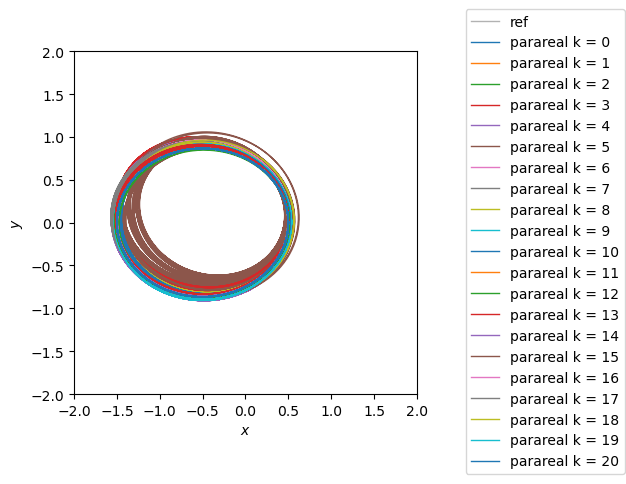

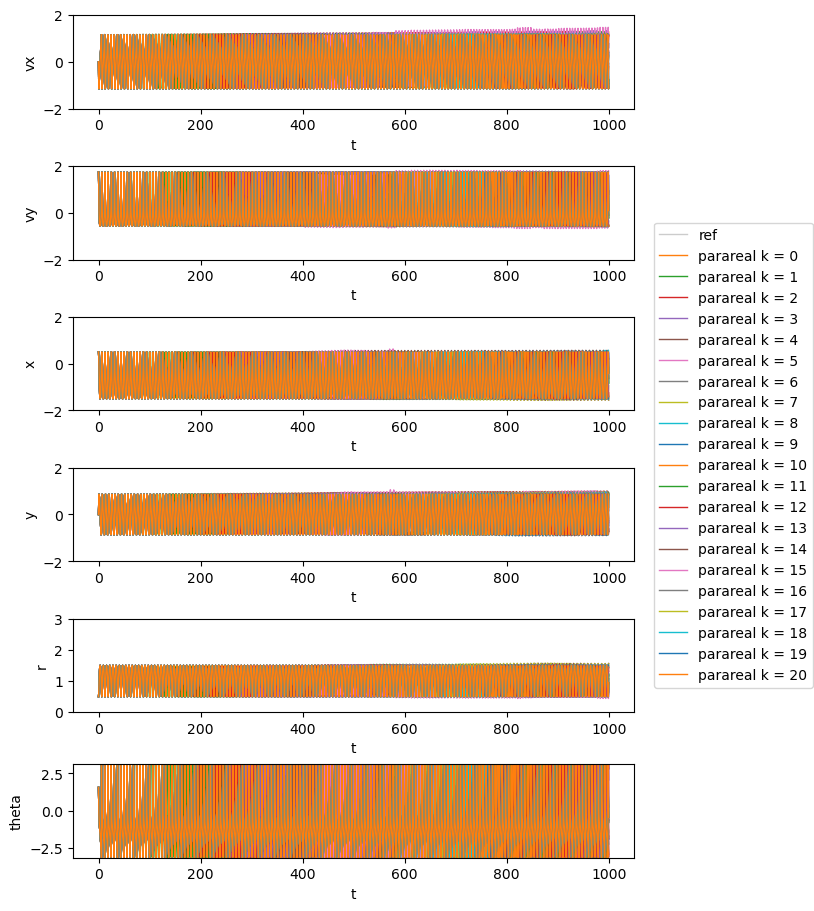

After alignment: 
	traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
	ref_traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
parareal k = 0 n=1 abs_traj_err = 5.647389932999457e-05
parareal k = 0 n=1 abs_traj_err_p = 5.3369316072841765e-05
parareal k = 0 n=1 abs_traj_err_q = 1.846665663977848e-05
parareal k = 0 n=1 abs_H_err = 3.2015234163740303e-06
After alignment: 
	traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
	ref_traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
parareal k = 1 n=1 abs_traj_err = 3.3823104336622004e-16
para

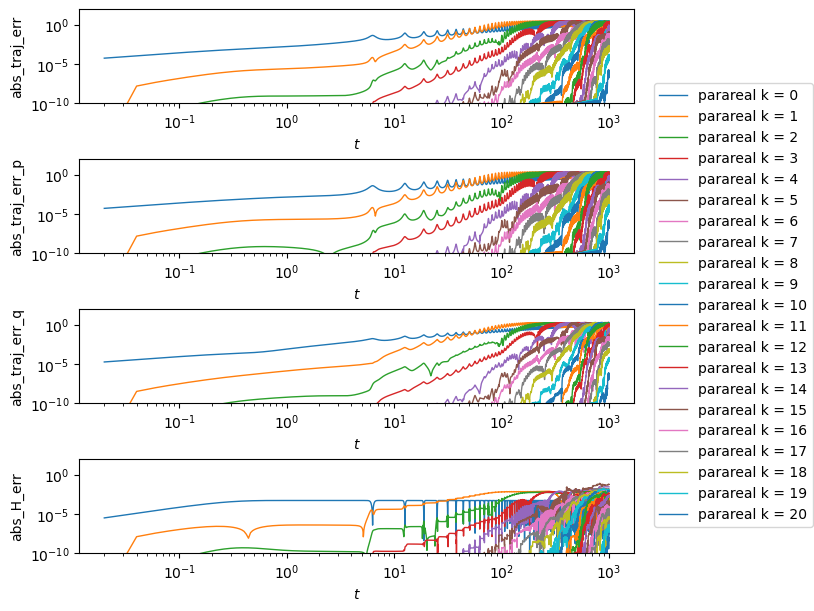

After alignment: 
	traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
	ref_traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
After alignment: 
	traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
	ref_traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
After alignment: 
	traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.        ], states=States(problem=OneBody(ecc=0.5), shape=(50001, 4)))
	ref_traj = OneBodyTrajectory(t_range=[0.0, 1000.0], dt=0.02, u0=[0.         1.73205081 0.5        0.  

/tmp/ipykernel_3367336/286721994.py:44: RuntimeWarning: divide by zero encountered in log10
  im = axes[i].imshow(np.log10(error_matrix), cmap='viridis', interpolation='none', aspect='auto', clim=clims[i],


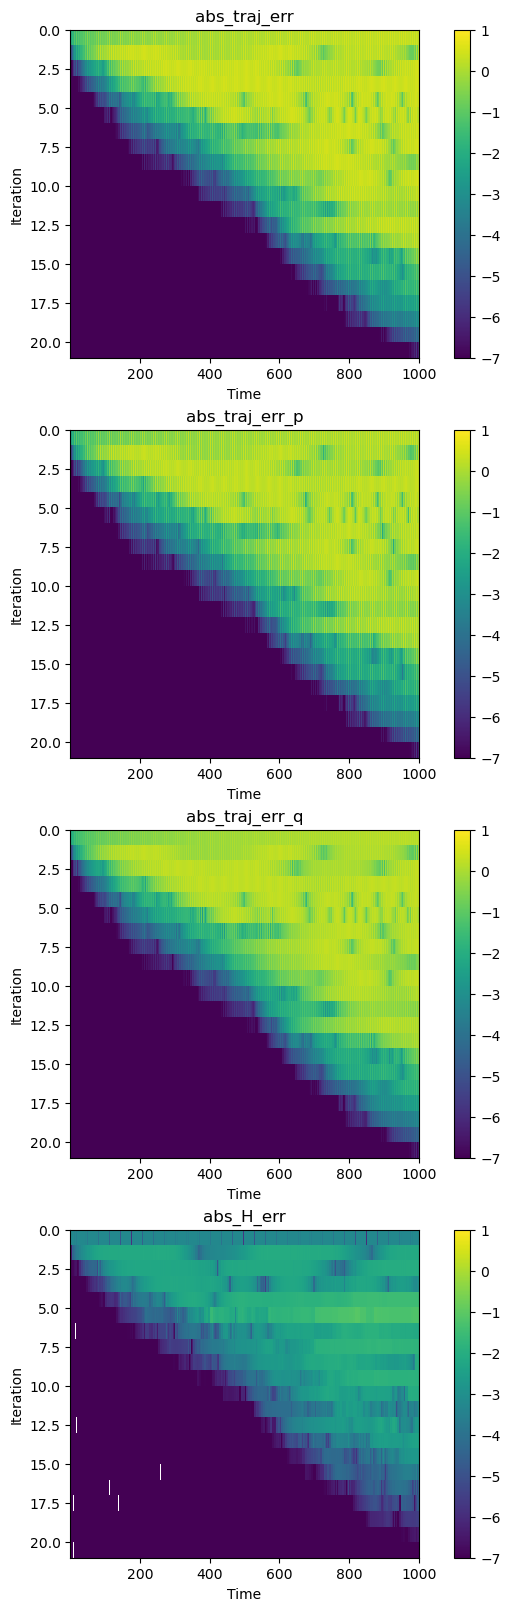

In [36]:
ecc = 0.5

ref_traj_idx = 1
ref_traj = Trajectory.load_from_file(
    REF_TRAJ_FILEPATHS[ecc][ref_traj_idx]["filepath"], 
    dt=REF_TRAJ_FILEPATHS[ecc][ref_traj_idx]["dt"],
    ecc=ecc,
)

# parent_dir = f"/workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208"
parent_dir = f"/workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192357"
# sub_dir = "plain"
# sub_dir = "plain_Dt_10_Nc_64"
# sub_dir = "procrustes_Dt_10"
sub_dir = "interpolative"

data_dir = os.path.join(parent_dir, sub_dir)
parareal_trajs = load_parareal_data(data_dir, K=20)
trajs = [ref_traj.select_with_interval(0.1)] + parareal_trajs
traj_labels = ['ref'] + ['parareal k = {}'.format(k) for k in range(len(trajs))]

trajs = [traj.select_between(0, 1000) for traj in trajs]

plot_xy(
    trajs, 
    axis_lims=[(-2, 2), (-2, 2)],
    figsize=(6, 4), 
    show_legend=True,
    legend_labels=traj_labels
)

plot_history(
    trajs,
    func_dict={
        'vx': lambda u: u[:, 0], 
        'vy': lambda u: u[:, 1],
        'x': lambda u: u[:, 2], 
        'y': lambda u: u[:, 3], 
        'r': lambda u: np.sqrt(u[:, 2]**2 + u[:, 3]**2),
        'theta': lambda u: np.arctan2(u[:, 2], u[:, 3]),
    },
    xlabel='t', 
    show_legend=True,
    legend_labels=traj_labels,
    ylims=[(-2, 2), (-2, 2), (-2, 2), (-2, 2), (0, 3), (-np.pi, np.pi)],
)

plot_errors(
    parareal_trajs, ref_traj, error_names=["abs_traj_err", "abs_traj_err_p", "abs_traj_err_q", "abs_H_err"], 
    legend_labels=traj_labels[1:], show_legend=True, 
    ylims=[(1e-10, 1e2)]*4, log_xscale=True, 
)

parareal_trajs = [traj.select_between(0, 1000) for traj in parareal_trajs]

plot_error_heatmaps(
    parareal_trajs, ref_traj, error_names=["abs_traj_err", "abs_traj_err_p", "abs_traj_err_q", "abs_H_err"], 
    clims=[(-7, 1)]*6,
)

Parareal config:
	algorithm: {'_name_': 'plain'}
	integration: {'Delta_t': 0.1, 'N': 10000, 'Nc': 1, 'Nf': 10, 'coarse_method': 'VelocityVerlet', 'fine_method': 'KahanLi8', 'niters': 20, 'use_float64x4': False}
	problem: {'_name_': '1body', 'ecc': 0.5}
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208/plain/k=0/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208/plain/k=1/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208/plain/k=2/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208/plain/k=3/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208/plain/k=4/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208/plain/k=5/u.csv
Loading data from /workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208/plain/k=6/u.csv
Loading data

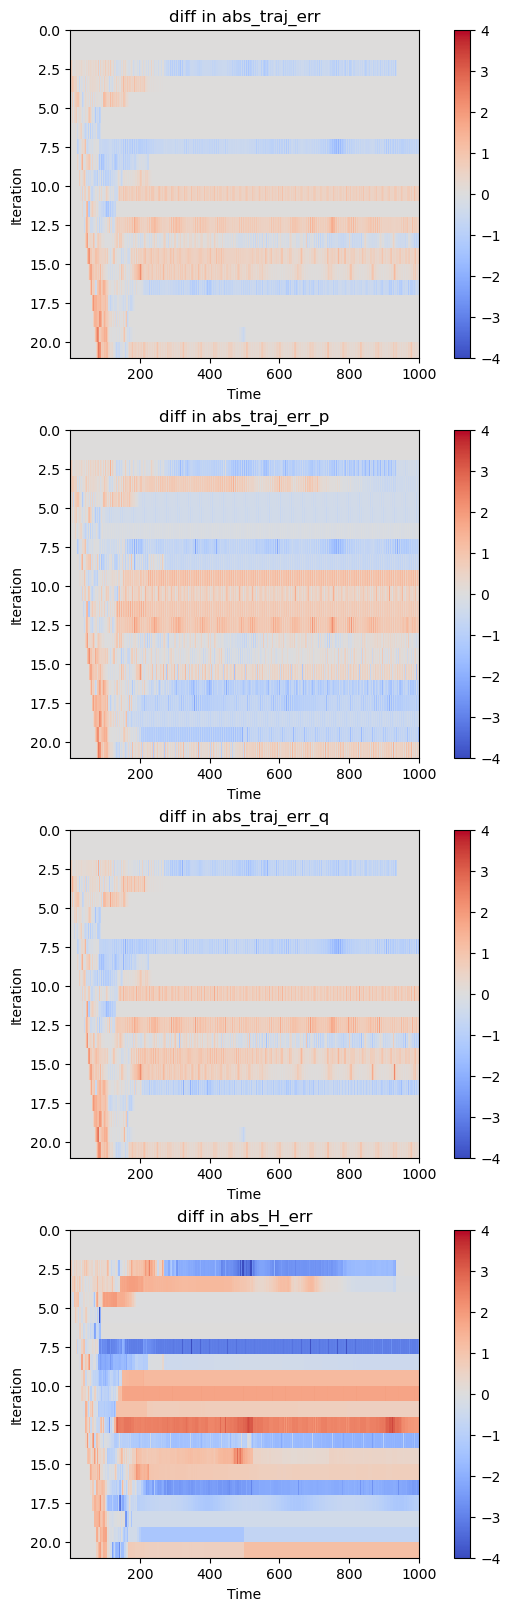

In [ ]:
ecc = 0.5

ref_traj_idx = 1
ref_traj = Trajectory.load_from_file(
    REF_TRAJ_FILEPATHS[ecc][ref_traj_idx]["filepath"], 
    dt=REF_TRAJ_FILEPATHS[ecc][ref_traj_idx]["dt"],
    ecc=ecc,
)

# parent_dir = f"/workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192208"
parent_dir = f"/workspace/projects_rui/learnsolnmap/out/1body/ecc=5e-1/1/202503192357"
sub_dir1 = "plain"
# sub_dir = "plain_Dt_10_Nc_64"
# sub_dir = "procrustes_Dt_10"
sub_dir2 = "interpolative"




data_dir1 = os.path.join(parent_dir, sub_dir1)
data_dir2 = os.path.join(parent_dir, sub_dir2)
parareal_trajs1 = load_parareal_data(data_dir1, K=20)
parareal_trajs2 = load_parareal_data(data_dir2, K=20)

parareal_trajs1 = [traj.select_between(0, 1000) for traj in parareal_trajs1]
parareal_trajs2 = [traj.select_between(0, 1000) for traj in parareal_trajs2]

plot_error_diff_heatmaps(
    parareal_trajs1, parareal_trajs2, ref_traj, 
    error_names=["abs_traj_err", "abs_traj_err_p", "abs_traj_err_q", "abs_H_err"],
    clims=[(-4, 4)]*4,
    min_log10_error=-7,
    max_log10_error=1,
)
